# Customer Churn Prediction Using Machine Learning

## Objective

The objective of this project is to develop a machine learning model capable of predicting whether a telecommunications customer is likely to churn based on demographic information, account details, subscribed services, and billing history.

---

### Machine Learning Problem

**Type:** Binary Classification

### Target Variable

**Churn**

- Yes → Customer leaves the company
- No → Customer remains with the company

---

### Dataset

IBM Telco Customer Churn Dataset

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
plt.style.use("ggplot")

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


# Load Dataset and Verify it's loaded successfully using df.head()

In [3]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Understand the Dataset
Before cleaning anything, let's inspect it.

In [4]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (7043, 21)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.describe(include="object")

/var/folders/gx/m8cfhfjn0clgmds10y844l7m0000gp/T/ipykernel_33968/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [10]:
df.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


Let's check datatype of every column

In [11]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Let's now check whether there are any missing values?

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Let's also check if we have redundant customers?

In [14]:
df.duplicated().sum()

np.int64(0)

In in above datatype check we found TotalCharges is <str> while it should have been float and the reason I found was due to " " single blank space so lets check how many rows have a blank string instead of a number.

In [15]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

Let's inspect those rows

It will filter the DataFrame and shows only the problematic rows.

In [16]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


# Data Cleaning

In this section, we clean the dataset by correcting data types, handling missing values, and preparing the data for analysis and machine learning.

We convert the hidden missing values (blank strings) into actual **NaN** values so pandas can recognize and handle them...

In [17]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [18]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Now converting TotalCharges to numeric (Now since blanks are NaN, pandas can safely convert the rest of the column to numbers.)

In [20]:
df['TotalCharges'] = pd.to_numeric(df["TotalCharges"])

Now lets verify the data type

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Dropping the missing rows as there are 11 rows missing and this ratio is small and also TotalCharges is important feature so it's better to drop it rather than replacing values which may affect the model training even more.

In [22]:
df.dropna(inplace=True)

In [23]:
print(f"New Shape: {df.shape}")
print()
print(df.isnull().sum())

New Shape: (7032, 21)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of understanding the dataset through summary statistics and visualizations. It helps identify trends, relationships, patterns, and anomalies before building machine learning models.

It's basically we are gonna ask dataset questions...

## How many customers churned?

In [24]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Now in percentages

In [25]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

Here we can see the data is imbalanced.

## Visualiztion 1

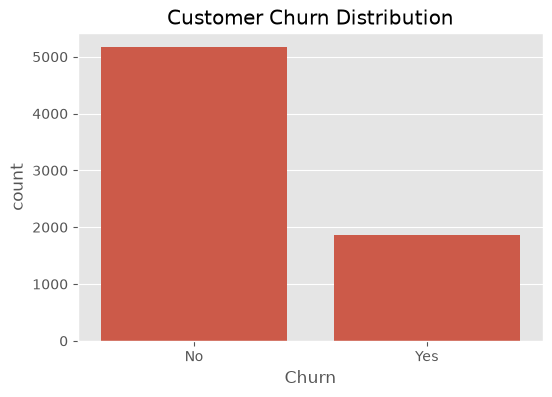

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.show()

Here we can see more customers stay than leave. So the dataset is imbalanced, which affects model evaluation.

## Visualization 2

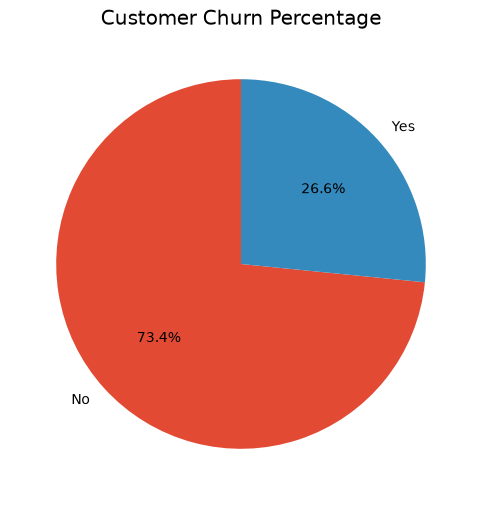

In [27]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Customer Churn Percentage")

plt.show()

## Do males churn more?
## Or females?

This creates a contingency table.

In [28]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


## Visualization

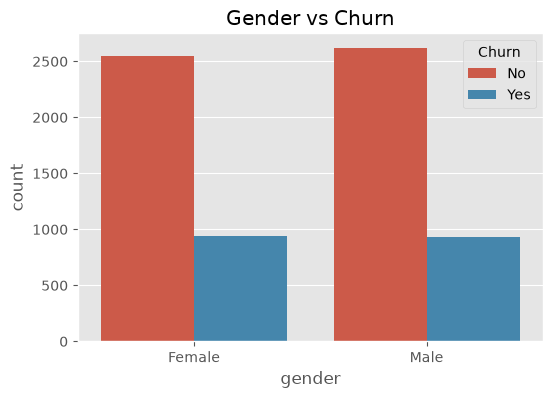

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Churn")

plt.show()

## Does contract type matter?

In [30]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


Let's plot it.

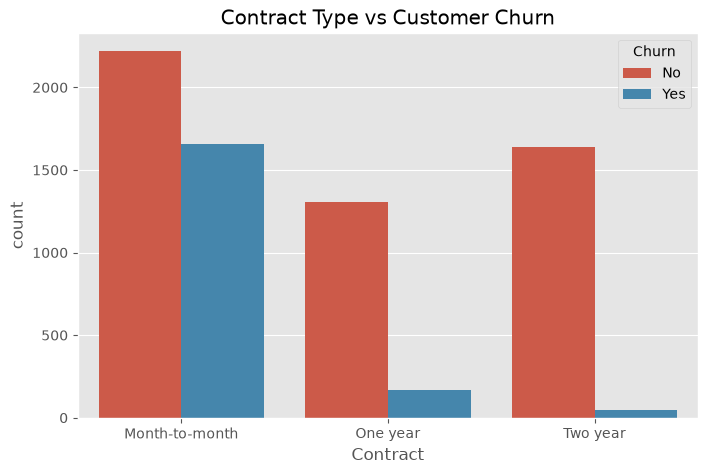

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Customer Churn")

plt.savefig("../reports/figures/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Target Variable Analysis

## How many customers leave the company?

### 1.1 Customer Churn Distribution

This analysis examines the distribution of the target variable (`Churn`) to understand how many customers stayed with the company versus how many customers left.

Understanding the class distribution is important because an imbalanced dataset may require special handling during model training and evaluation.

In [33]:
# Count the no. of customers in each churn category
churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [34]:
# Calculate the percentage distribution
churn_percentage = df["Churn"].value_counts(normalize=True)*100

print(churn_percentage.round(2))

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


## Bar Chart

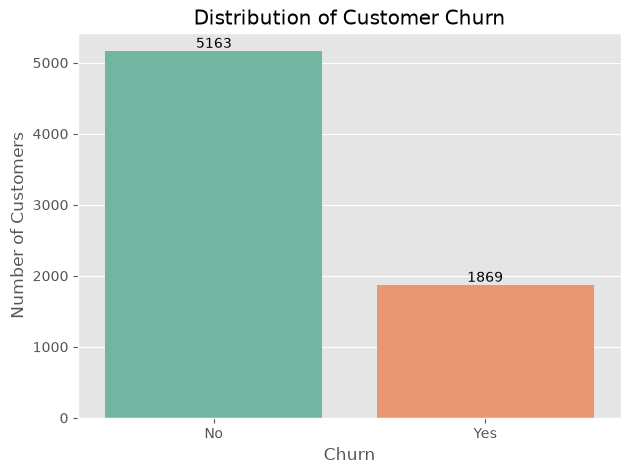

In [35]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="Set2",
    legend=False
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.savefig(
    "../reports/figures/churn_distribution_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Pie Chart

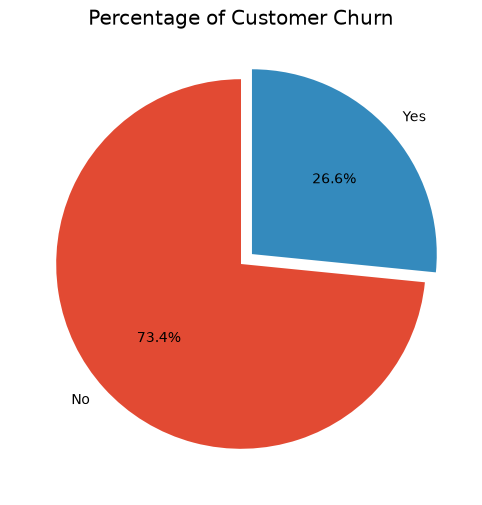

In [36]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    explode=[0, 0.08]
)

plt.title("Percentage of Customer Churn")
plt.ylabel("")

plt.savefig(
    "../reports/figures/churn_distribution_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Approximately **73%** of customers remained with the company, while **27%** churned.
- The dataset is moderately imbalanced, with more customers staying than leaving.
- Since the imbalance is not extreme, standard classification algorithms can be used, but evaluation should include metrics such as Precision, Recall, F1-score, and ROC-AUC instead of relying only on Accuracy.

# Customer Demographics
### 2.2 Customer Demographics Analysis

This section explores the relationship between customer demographic characteristics and churn behavior. Understanding these relationships helps identify which customer groups are more likely to leave the company.

### Gender Vs Churn

In [37]:
gender_churn = pd.crosstab(df["gender"], df["Churn"])

display(gender_churn)

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


In [38]:
gender_churn_percent = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

display(gender_churn_percent.round(2))

Churn,No,Yes
gender,,
Female,73.04,26.96
Male,73.80,26.20


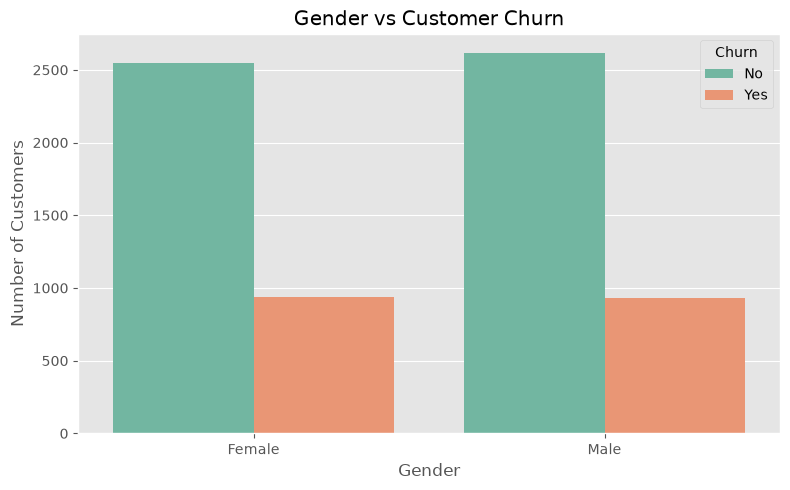

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn",
    palette="Set2"
)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/gender_vs_churn.png",
    dpi=300
)

plt.show()

### Observation
The churn distribution between male and female customers appears very similar. Gender alone does not appear to be a strong predictor of customer churn.

### 2.2 Senior Citizen vs Customer Churn

This analysis examines whether senior citizens have a higher likelihood of churning compared to non-senior customers.

In [40]:
senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"])

display(senior_churn)

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


In [41]:
senior_churn_percent = (
    pd.crosstab(
        df["SeniorCitizen"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

display(senior_churn_percent)

Churn,No,Yes
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68


Instead of showing 0 1 let's make it readable

In [42]:
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

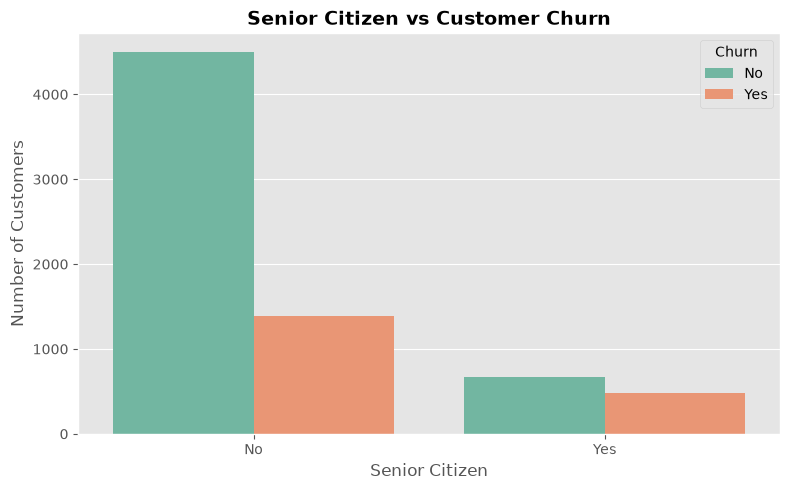

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="SeniorCitizenLabel",
    hue="Churn",
    palette="Set2"
)

plt.title("Senior Citizen vs Customer Churn", fontsize=14, fontweight="bold")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/seniorcitizen_vs_churn.png",
    dpi=300
)

plt.show()

### Observation

- Most customers are not senior citizens.
- Senior citizens show a noticeably higher churn rate than non-senior customers.
- This suggests that age group may be an important factor influencing customer retention.

### 2.3 Partner vs Customer Churn

This analysis investigates whether customers with a partner are more likely to remain with the company compared to customers without a partner.

In [44]:
partner_churn = pd.crosstab(df["Partner"], df["Churn"])

display(partner_churn)

Churn,No,Yes
Partner,,
No,2439,1200
Yes,2724,669


In [45]:
partner_churn_percent = (
    pd.crosstab(
        df["Partner"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

display(partner_churn_percent)

Churn,No,Yes
Partner,,
No,67.02,32.98
Yes,80.28,19.72


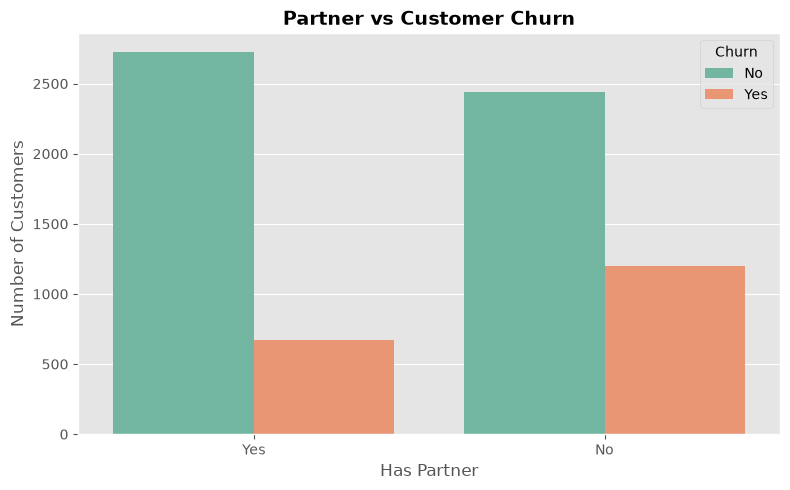

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Partner",
    hue="Churn",
    palette="Set2"
)

plt.title("Partner vs Customer Churn", fontsize=14, fontweight="bold")
plt.xlabel("Has Partner")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/partner_vs_churn.png",
    dpi=300
)

plt.show()

### Observation
- Customers with a partner appear to churn less frequently than customers without a partner.
- Having a partner may be associated with greater customer retention.

### 2.4 Dependents vs Customer Churn

This analysis explores the relationship between having dependents and customer churn.

In [47]:
dependents_churn = pd.crosstab(df["Dependents"], df["Churn"])

display(dependents_churn)

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1773,326


In [48]:
dependents_churn_percent = (
    pd.crosstab(
        df["Dependents"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

display(dependents_churn_percent)

Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.47,15.53


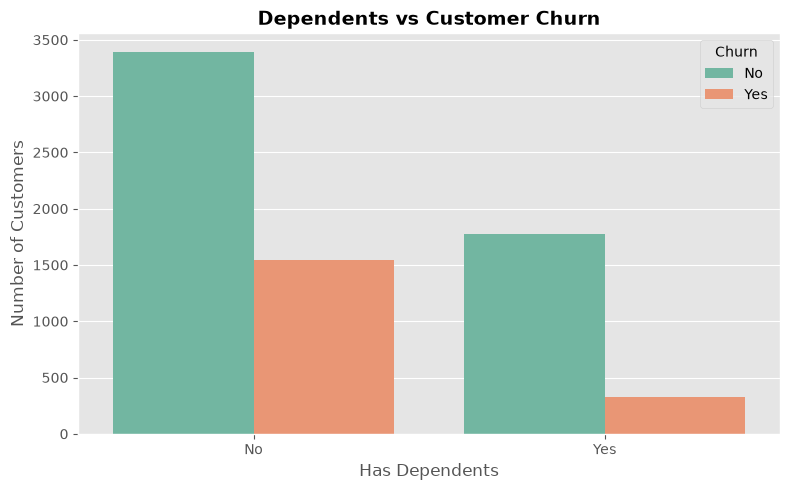

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn",
    palette="Set2"
)

plt.title("Dependents vs Customer Churn", fontsize=14, fontweight="bold")
plt.xlabel("Has Dependents")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/dependents_vs_churn.png",
    dpi=300
)

plt.show()

### Observation
- Customers with dependents have a lower churn rate.
- Customers without dependents are more likely to leave the company.

### 3.1 Contract Type vs Customer Churn

This analysis investigates whether the type of customer contract influences churn behavior. Customers with longer contracts are generally expected to exhibit higher retention rates.

In [50]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

display(contract_churn)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [51]:
contract_churn_percent = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

display(contract_churn_percent)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


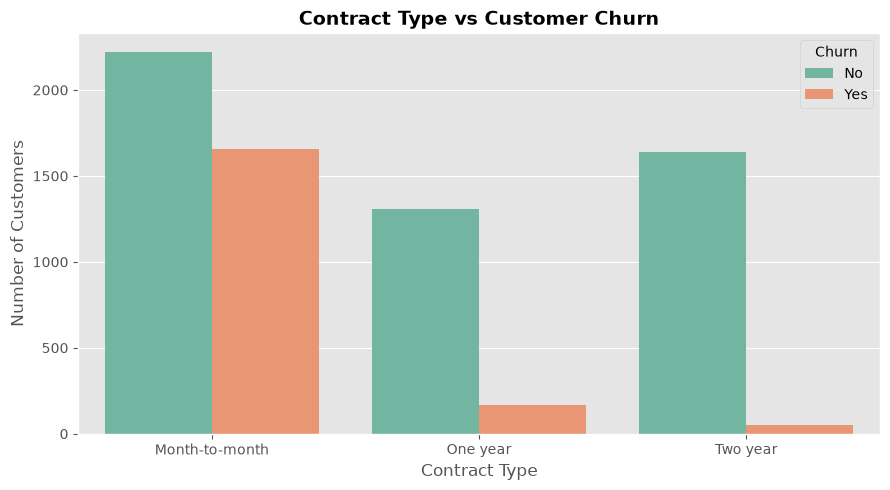

In [52]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2"
)

plt.title("Contract Type vs Customer Churn",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/contract_vs_churn.png",
    dpi=300
)

plt.show()

### Observation 
- Month-to-month customers have the highest churn.
- One-year contract customers churn much less.
- Two-year contract customers rarely churn.
This is a major business insight.

### 3.2 Internet Service vs Churn

Which internet service experiences the highest churn?

In [53]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

display(internet_churn)

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [54]:
internet_churn_percent = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

display(internet_churn_percent)

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


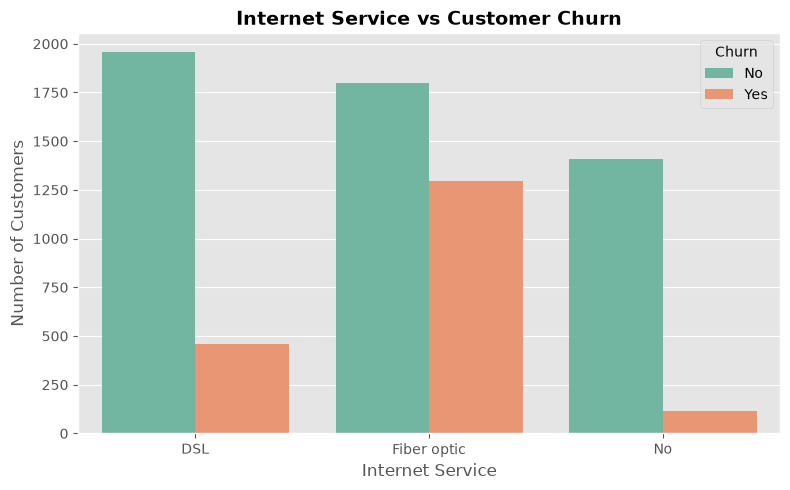

In [55]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="Set2"
)

plt.title("Internet Service vs Customer Churn",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/internet_service_vs_churn.png",
    dpi=300
)

plt.show()

### 3.3 Payment Method vs Churn

Do certain payment methods have higher churn rates?

In [56]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

display(payment_churn)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


In [57]:
payment_churn_percent = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

display(payment_churn_percent)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


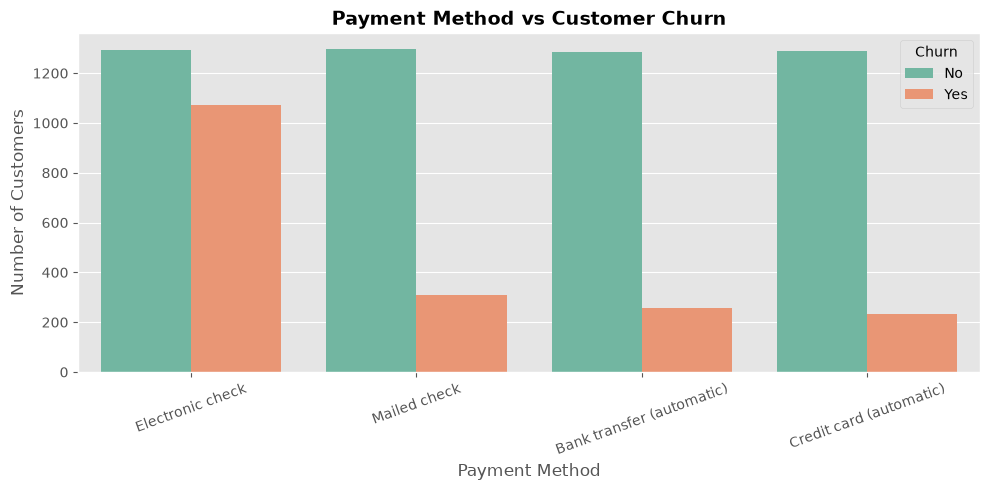

In [58]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    palette="Set2"
)

plt.xticks(rotation=20)

plt.title("Payment Method vs Customer Churn",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/payment_method_vs_churn.png",
    dpi=300
)

plt.show()

### 4.1 Tenure vs Customer Churn

This analysis examines the relationship between customer tenure and churn. Customer tenure represents the number of months a customer has remained with the company.

Summary Statistics

In [59]:
df.groupby("Churn")["tenure"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.65,24.08,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


## Histogram

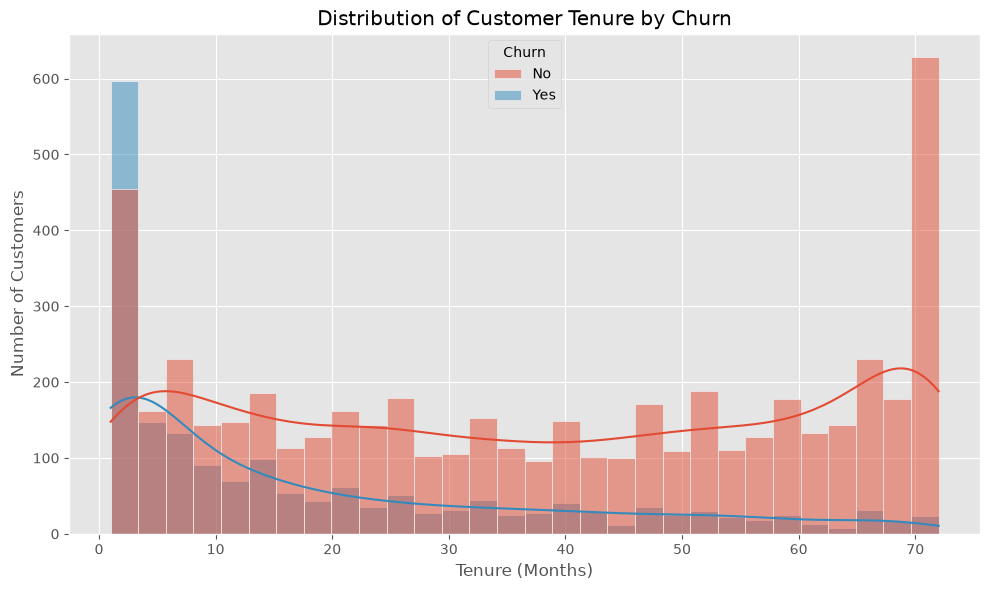

In [60]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    multiple="layer"
)

plt.title("Distribution of Customer Tenure by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/tenure_distribution.png",
    dpi=300
)

plt.show()

## Box Plot

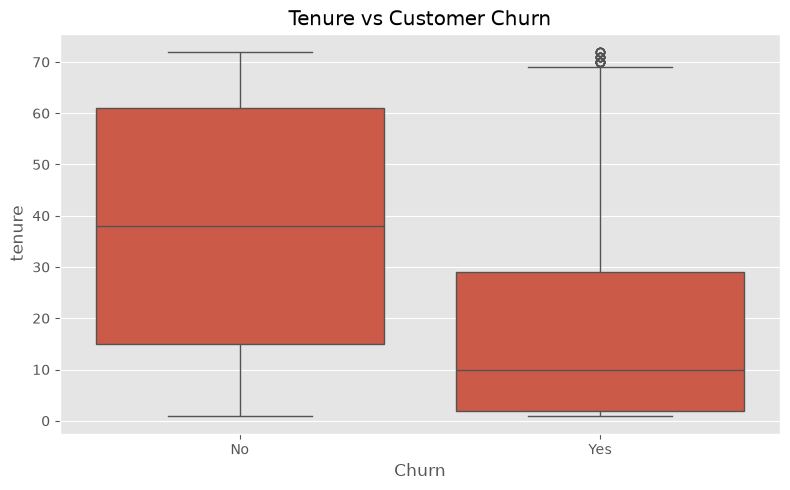

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Customer Churn")

plt.tight_layout()

plt.savefig(
    "../reports/figures/tenure_boxplot.png",
    dpi=300
)

plt.show()

### Observation
- Customers with low tenure churn much more.
- Long-term customers rarely churn.

### 4.2 Monthly Charges vs Churn

Do customers with higher monthly bills leave more often?

In [62]:
df.groupby("Churn")["MonthlyCharges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.31,31.09,18.25,25.10,64.45,88.48,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.20,118.35


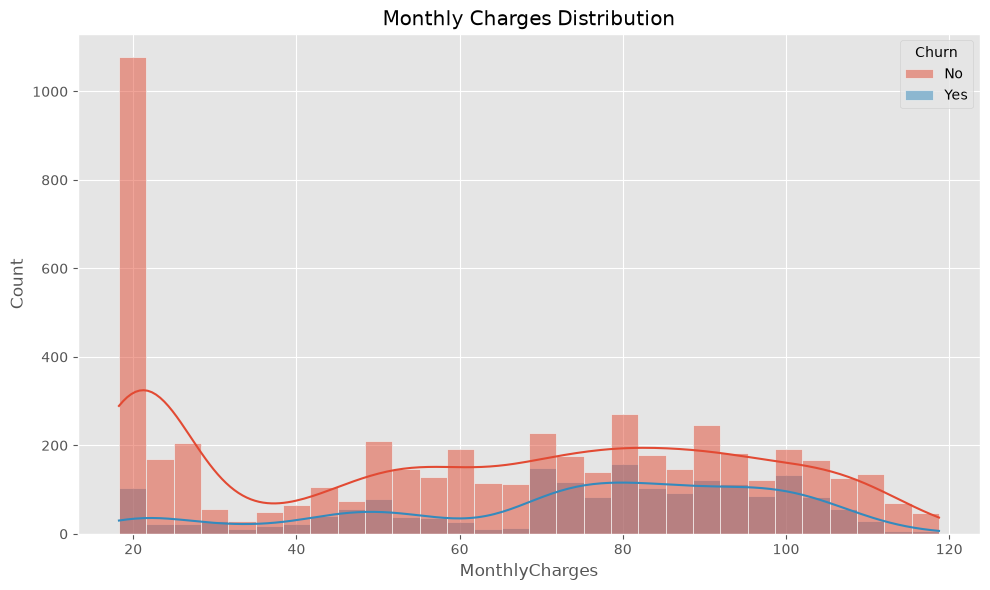

In [63]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    kde=True,
    multiple="layer"
)

plt.title("Monthly Charges Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/figures/monthlycharges_distribution.png",
    dpi=300
)

plt.show()

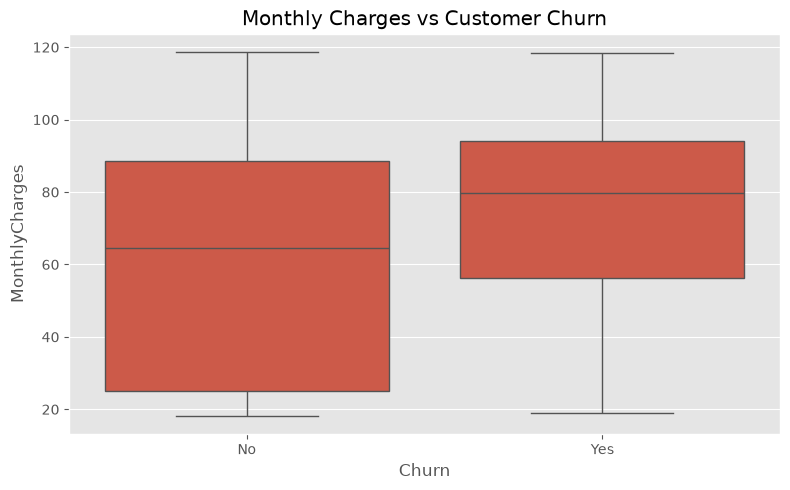

In [64]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Customer Churn")

plt.tight_layout()

plt.savefig(
    "../reports/figures/monthlycharges_boxplot.png",
    dpi=300
)

plt.show()

### 4.3 Total Charges vs Churn
Does the total amount spent relate to churn?

In [65]:
df.groupby("Churn")["TotalCharges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,2555.34,2329.46,18.80,577.83,1683.60,4264.12,8672.45
Yes,1869.0,1531.80,1890.82,18.85,134.50,703.55,2331.30,8684.80


/var/folders/gx/m8cfhfjn0clgmds10y844l7m0000gp/T/ipykernel_33968/2463969003.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(


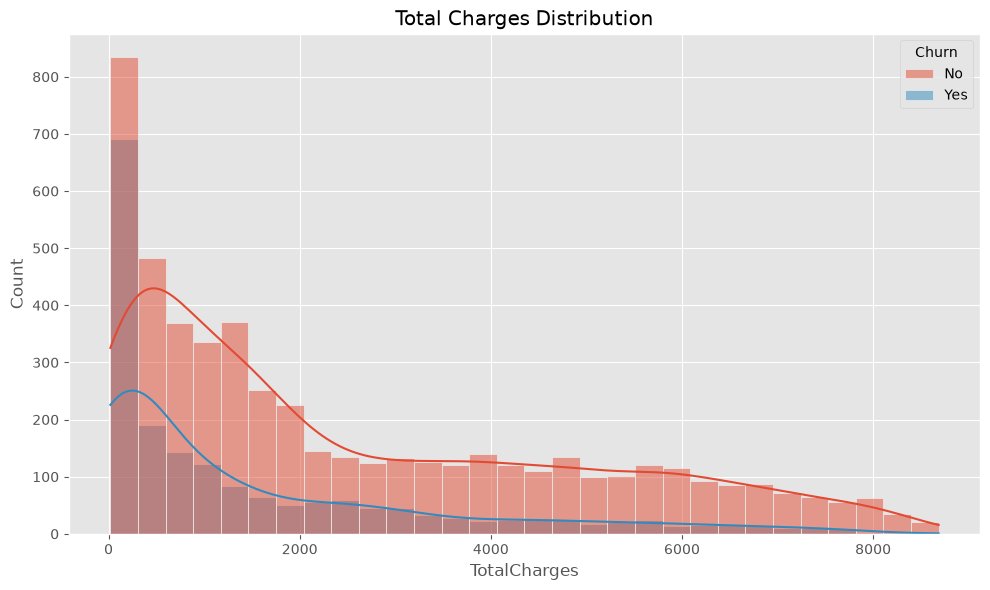

In [66]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    bins=30,
    kde=True,
    multiple="layer"
)

plt.title("Total Charges Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/figures/totalcharges_distribution.png",
    dpi=300
)

plt.show()

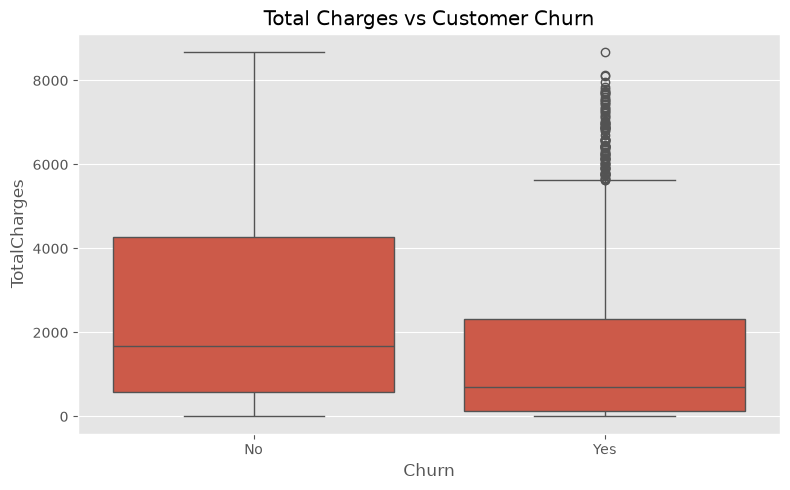

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Customer Churn")

plt.tight_layout()

plt.savefig(
    "../reports/figures/totalcharges_boxplot.png",
    dpi=300
)

plt.show()

### 5.1 Correlation Analysis

In [68]:
numeric_df = df.select_dtypes(include=["number"])

numeric_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


## Correlation Matrix

In [69]:
corr = numeric_df.corr()

corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


## Heatmap

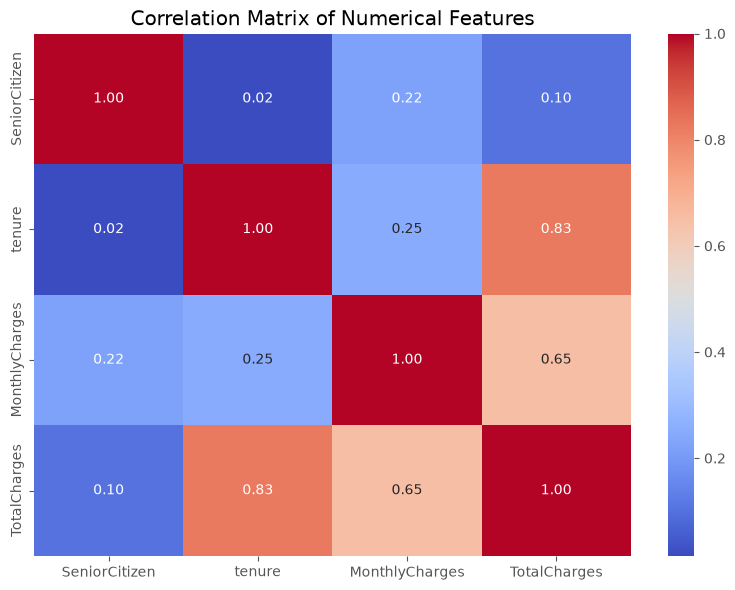

In [70]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    dpi=300
)

plt.show()

# Feature Engineering and Data Preparation

Machine learning algorithms require numerical input features. In this section, categorical variables are encoded, irrelevant features are removed, and the dataset is prepared for model training.

## Making a copy as we never modify our original DatFrame
We do this as if we make a mistake, our original dataset remains untouched.

In [71]:
ml_df = df.copy()

## Removing Customer ID
we gonna remove this as every customer has unique ID but they don't contain any meaningful pattens related to churn. They're just identifiers and should not be used as features.

In [72]:
ml_df.drop(columns="customerID", inplace=True)

## Encode the Target Variable

Current values:

Yes

No

ML models require numbers.


No -> 0

Yes -> 1

In [73]:
ml_df["Churn"] = ml_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

Verify

In [74]:
ml_df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

Identify Categorical Columns

In [75]:
categorical_columns = ml_df.select_dtypes(
    include=["object", "string"]
).columns

categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'SeniorCitizenLabel'],
      dtype='str')

## One-Hot Encoding

We will use this encoding because most features are nominal categories.

In [76]:
ml_df = pd.get_dummies(
    ml_df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

Here we did drop_first = Ture.

Why?

eg: Without dropping:

```bash
Gender_Male
Gender_Female
```

If Male = 1, Female is already known to be 0.

Keeping both creates redundant info.

So we drop one column.

Check Shape

In [77]:
print("Original Shape :", df.shape)
print("Encoded Shape  :", ml_df.shape)

Original Shape : (7032, 22)
Encoded Shape  : (7032, 32)


Here we see the columns are increased as categorical variables are expanded into multiple binary columns.

## Features & Target

In [78]:
X = ml_df.drop("Churn", axis=1)
y = ml_df["Churn"]

## Verify

In [79]:
print(X.shape)
print(y.shape)

(7032, 31)
(7032,)


## Train-Test Split

We gonna use industry-standard 80-20 split.

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Why stratify=y?

Our dataset isn't perfectly balanced (about 73% "No", 27% "Yes").

Using stratify=y ensures that both the training and testing sets maintain roughly the same class distribution as the original dataset.

Without stratification, one split could accidentally contain a much higher proportion of one class, leading to biased evaluation.

## Verify Split

In [81]:
print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (5625, 31)
Testing Set  : (1407, 31)


## Feature Scaling

Not every model requires scaling.

Models like:

- Logistic Regression
- KNN
- SVM

perform better with standardized features.

Tree-based models (Decision Tree, Random Forest) generally do not require it.

We'll create scaled copies of the data so we can use them where appropriate.

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)